In [221]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import DBSCAN, OPTICS
import pandas as pd
from scipy.ndimage import sobel, uniform_filter1d
# from scipy.interpolate import unifor
import scipy

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

In [222]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
mission_32 = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
mission_31 = 'ArgusFF_20211013T163100Z_RectifiedVideo.avi'
# /Users/mleclair/phd/code/dunex/data/argus/
file = mission_32

os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

In [223]:
def normalize(x, scale=255):
    x = (x - x.min())
    return x/x.max() * scale

In [224]:
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 1
timestack = np.zeros((N, H//skip, W))
stop = 300
# stop = np.inf

for i in tqdm(range(min(N, stop))):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


100%|██████████| 300/300 [00:00<00:00, 542.97it/s]


In [225]:
timestack = timestack[:300, ...]

In [226]:
s = normalize(
        (timestack - uniform_filter1d(timestack.mean(axis=2), 20, axis=0)[..., np.newaxis])
    )
s.shape

(300, 1600, 500)

In [227]:
timestack.shape

(300, 1600, 500)

: 

In [187]:
peaks = []
surf_zone_min = 0
surf_zone_max = 500
s = sobel(
        normalize(
            (timestack - uniform_filter1d(timestack.mean(axis=2), 20, axis=0)[..., np.newaxis])
        )
    )

for i in tqdm(range(0, 1600)):
    p = np.argsort(
        # s.T[:, i, surf_zone_min:surf_zone_max],
        # sobel(timestack[:, i, surf_zone_min:surf_zone_max].T),
        sobel(s[:, i, surf_zone_min:surf_zone_max].T),
        axis=0)[::-1]
    peaks.append(
        p+surf_zone_min
    )
peaks = np.array(peaks)
# peaks = np.swapaxes(peaks, 1, 2)
# peaks = np.swapaxes(peaks, 0, 1)
print(peaks.shape)

100%|██████████| 1600/1600 [00:07<00:00, 204.69it/s]


(1600, 500, 300)


(array([[  0.,   0.,   0., ...,  99., 298., 103.],
        [  0.,   0.,   0., ...,  97., 298., 105.],
        [  0.,   0.,   0., ...,  96., 294., 110.],
        ...,
        [  0.,   0.,   0., ...,  26., 348., 126.],
        [  0.,   0.,   0., ...,  21., 360., 119.],
        [292.,   0.,   0., ...,   2., 204.,   0.]]),
 array([-1.        , -0.65932895, -0.31865791,  0.02201314,  0.36268418,
         0.70335523,  1.04402628,  1.38469732,  1.72536837,  2.06603941,
         2.40671046]),
 <a list of 300 BarContainer objects>)

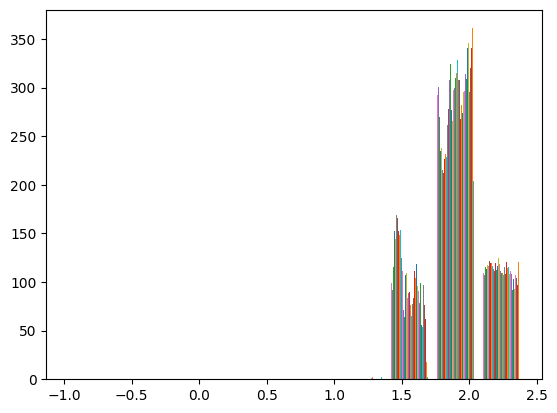

In [188]:
plt.hist(np.log10(
        normalize(
            (timestack - uniform_filter1d(timestack.mean(axis=2), 20, axis=0)[..., np.newaxis])[:, 50, :].T
        )+1e-1
    ),)

(300, 1600, 500)


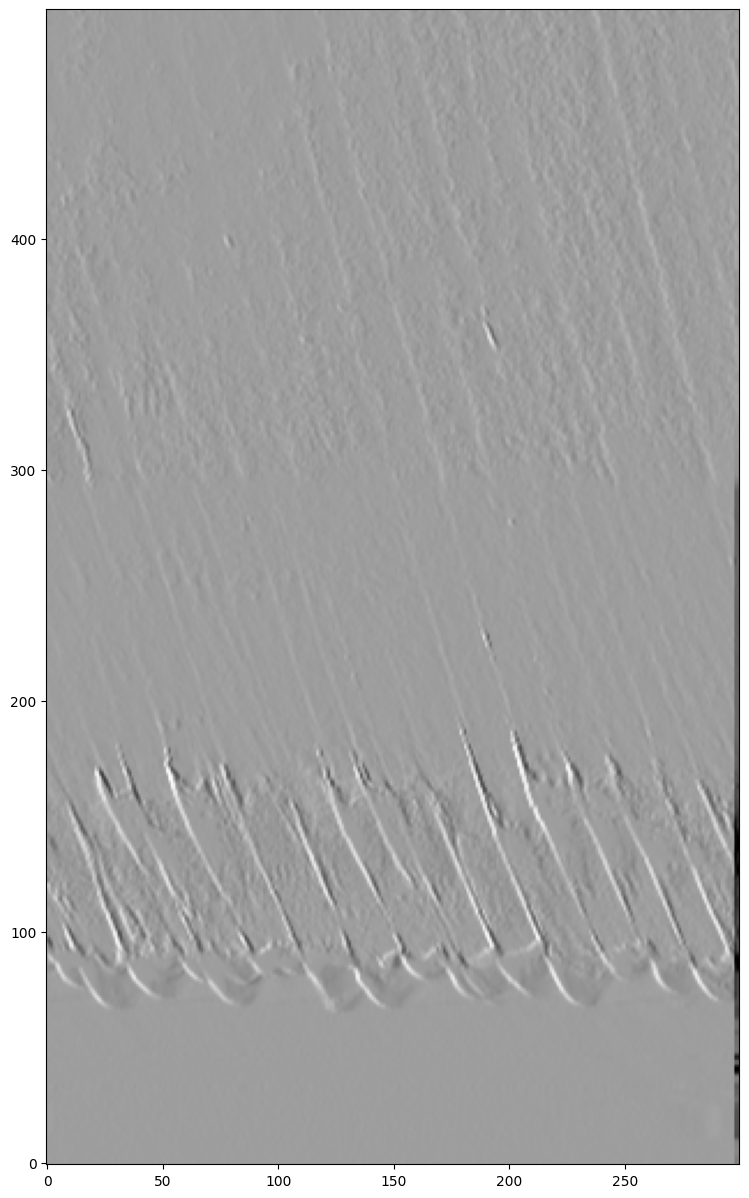

In [189]:
print(timestack.shape)
plt.figure(figsize=(15, 15))
plt.imshow(
    sobel(
        timestack[:, 50, :].T
    ),
    # vmin=1.9, vmax=2.5
)

(300, 1600, 500)


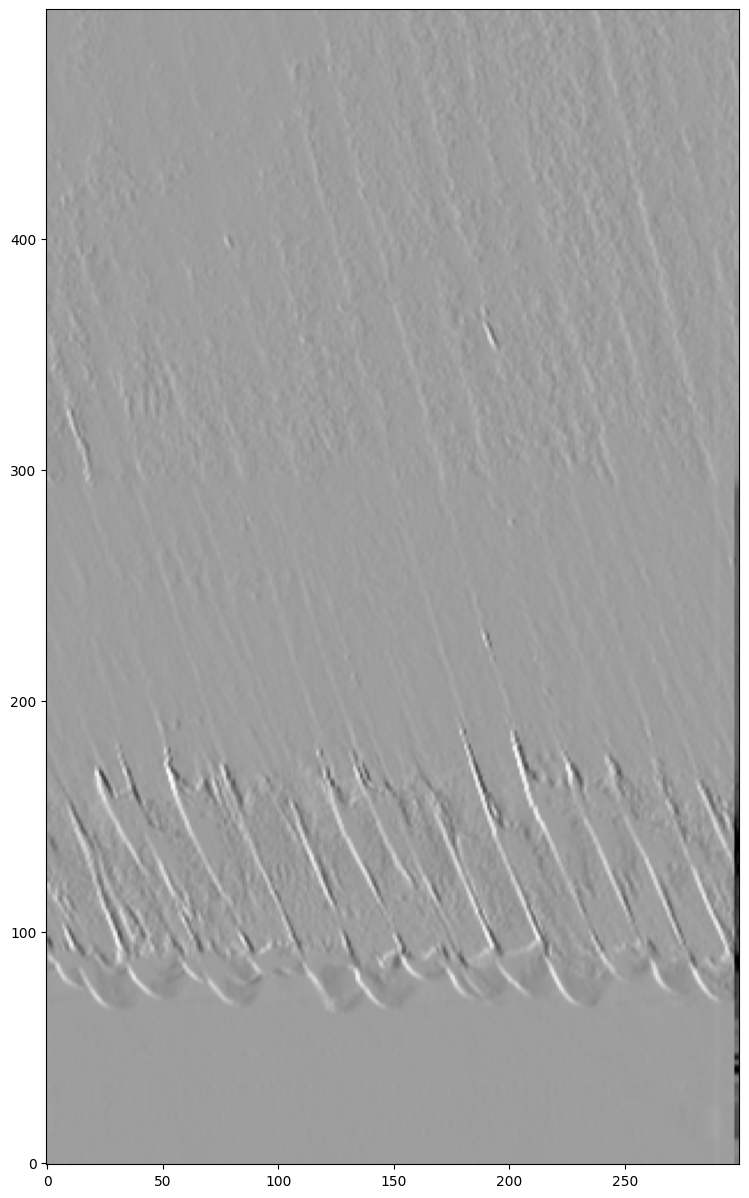

In [190]:
print(timestack.shape)
plt.figure(figsize=(15, 15))
plt.imshow(
    sobel(
        normalize(
            (timestack - uniform_filter1d(timestack.mean(axis=2), 20, axis=0)[..., np.newaxis])[:, 50, :].T
        ),
    ),
    # vmin=1.9, vmax=2.5
)

In [191]:
# # np.array([np.arange(N_T)]*N_X). T.flatten().shape
# np.array([np.arange(N_X)]*N_T).flatten().shape
# peaks.shape

In [192]:
N_T, N_X, N_Y = timestack.shape
N_PEAKS = peaks.shape[2]
N_PEAKS = 5
rpeaks = np.swapaxes(peaks, 1, 2)
rpeaks = np.swapaxes(peaks, 0, 1)
flat_peaks = np.hstack(
    [np.array([
            np.array([np.arange(N_T)]*N_X).T.flatten(),
            np.array([np.arange(N_X)]*N_T).flatten(),
            rpeaks[..., i].flatten()
        ]) for i in range(N_PEAKS)])
    
print(flat_peaks.shape)
print(flat_peaks)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

IndexError: index 1599 is out of bounds for axis 0 with size 300

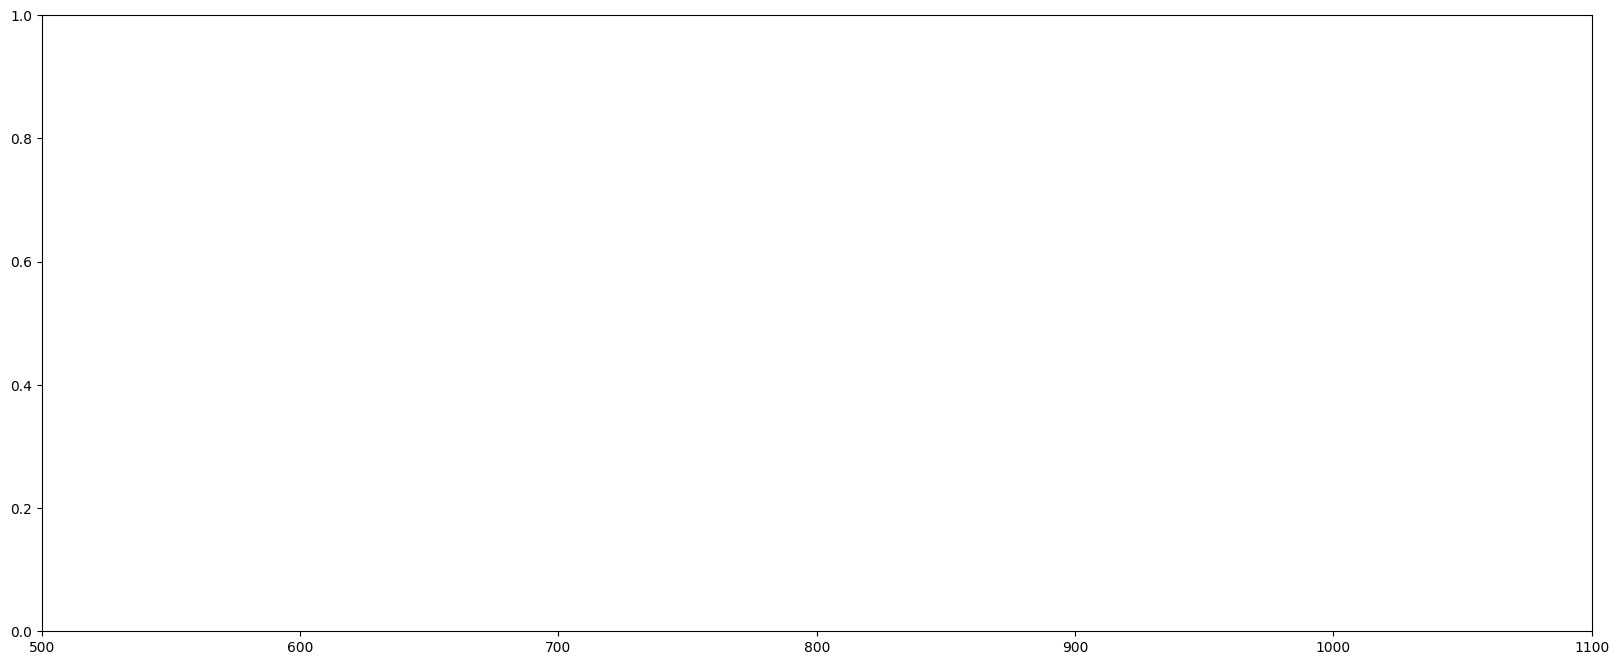

In [ ]:
plt.figure(figsize=(20, 8))
plt.xlim([500, 1100])
plt.imshow(timestack[i, :, :].T)
for i in range(300):
    mask = (flat_peaks[0]==i)
    plt.scatter(
        flat_peaks[1, mask],
        flat_peaks[2, mask],
    )

In [ ]:
labels= []
for i in range(N_T):
    c = DBSCAN(eps=5, min_samples=20).fit(flat_peaks[:, flat_peaks[0]==i].T)
    labels.append(c.labels_)


In [ ]:
# c = DBSCAN(eps=5, min_samples=10).fit(flat_peaks.T)
# labels = c.labels_
np.unique(labels[50].shape)

array([8000])

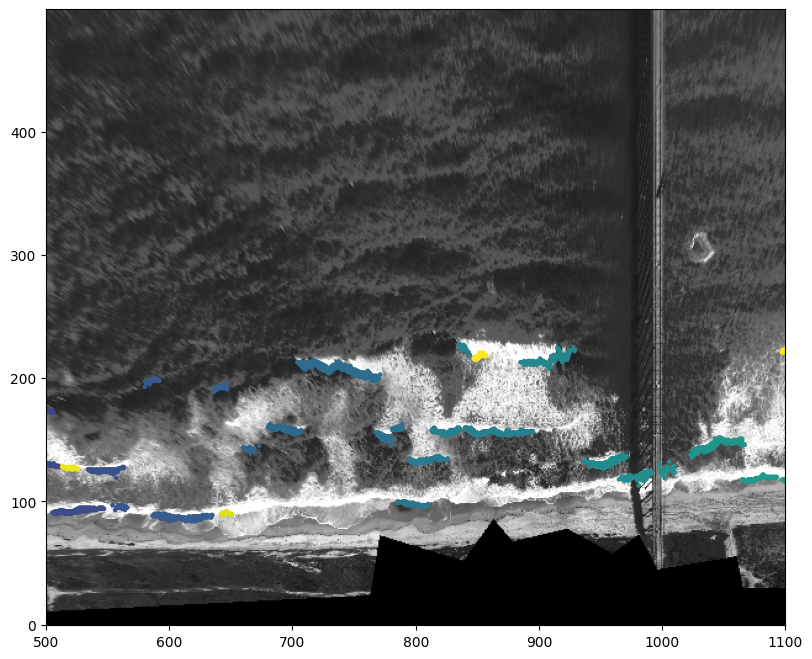

In [ ]:
i = 50
plt.figure(figsize=(20, 8))
plt.xlim([500, 1100])
plt.imshow(timestack[i, :, :].T)
mask = (flat_peaks[0]==i) #

plt.scatter(
    flat_peaks[1, mask][(labels[i] > 0)],
    flat_peaks[2, mask][(labels[i] > 0)],
    c=labels[i][labels[i]>0],
    cmap='viridis',
    s=5
)

 58%|█████▊    | 175/300 [00:42<00:30,  4.11it/s]


KeyboardInterrupt: 

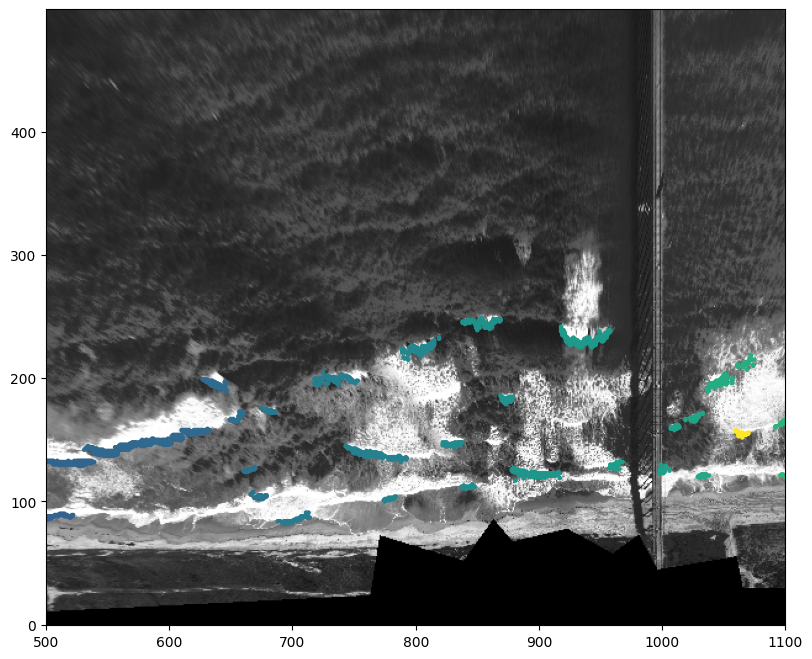

In [ ]:
# plt.figure(figsize=(20, 8))
# plt.xlim([500, 1100])
for i in tqdm(range(N_T)):
    plt.figure(figsize=(20, 8))
    plt.xlim([500, 1100])
    plt.imshow(timestack[i, :, :].T)
    # mask = (flat_peaks[0]==i) & (labels > 0)
    # plt.scatter(
    #     flat_peaks[1, mask],
    #     flat_peaks[2, mask],
    #     c=labels[mask],
    #     cmap='viridis',
    #     s=2
    # )
    mask = (flat_peaks[0]==i) #
    plt.scatter(
        flat_peaks[1, mask][(labels[i] > 0)],
        flat_peaks[2, mask][(labels[i] > 0)],
        c=labels[i][labels[i]>0],
        cmap='viridis',
        s=5
    )
    plt.savefig(f'../figures/dbscan{i:04}.png')
    plt.axis('off')
    plt.clf()
    plt.close()
! ffmpeg -r 5 -pattern_type glob -i '../figures/dbscan*.png' -c:v libx264 movie.mp4 -y


In [ ]:
cap = cv2.VideoCapture(os.path.join(dir, file))

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = 2
SECONDS = 100
NFRAMES = FPS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()
cv2.destroyAllWindows()

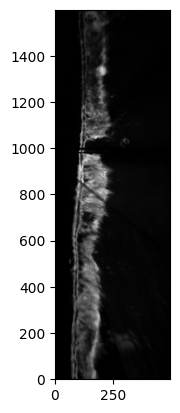

In [ ]:
plt.imshow(timestack.var(axis=0))

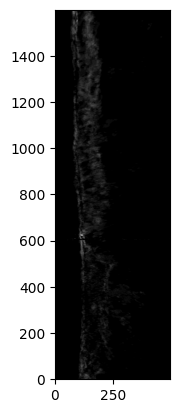

In [ ]:
plt.imshow(count)

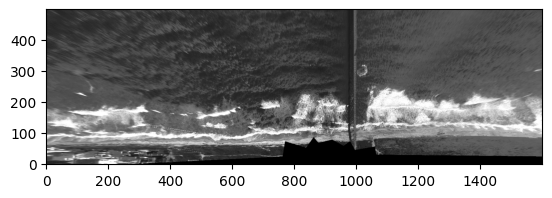

In [ ]:
plt.imshow(timestack[0, ...].T)

In [ ]:
timestack.shape

(120, 1600, 500)

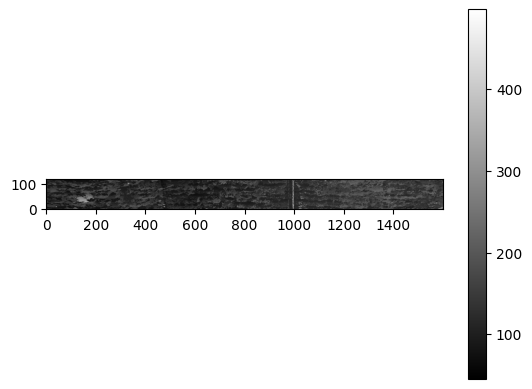

In [ ]:
plt.imshow(peaks[:, 0, :].T)
plt.colorbar()

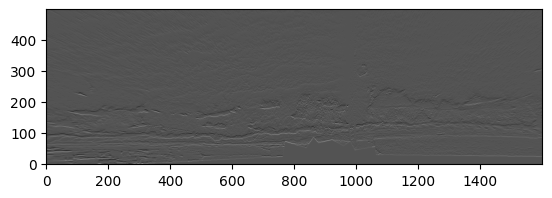

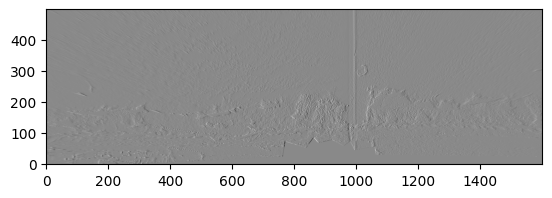

In [ ]:
plt.imshow(np.gradient(timestack[0, ...].T)[0])
plt.figure()
plt.imshow(np.gradient(timestack[0, ...].T)[1])

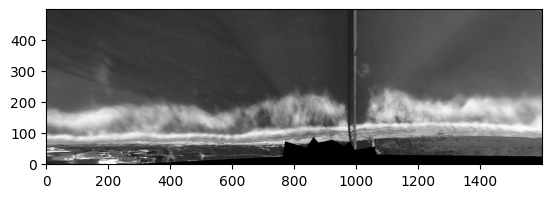

In [ ]:
plt.imshow(timestack.mean(axis=0).T)

In [ ]:
surf_zone_max

500

In [197]:
peaks = []
surf_zone_min = 0
surf_zone_max = 500
s = timestack
# s = normalize(
#         (timestack - uniform_filter1d(timestack.mean(axis=2), 20, axis=0)[..., np.newaxis])
#     )

for i in tqdm(range(0, 1600)):
    p = np.argsort(
        # s.T[:, i, surf_zone_min:surf_zone_max],
        # sobel(timestack[:, i, surf_zone_min:surf_zone_max].T),
        sobel(s[:, i, surf_zone_min:surf_zone_max].T),
        axis=0)[::-1]
    peaks.append(
        p+surf_zone_min
    )
peaks = np.array(peaks)

100%|██████████| 1600/1600 [00:07<00:00, 221.11it/s]


In [196]:
peaks[i][:c].shape

(5, 300)

In [215]:
# DBSCAN to get rid of random points

# This needs some work. I feel like I should be able to get the full wave coming to shore in one piecem at least for some of these. And then maybe merge them w/ ransac?
c = 5
labels = []
filtered_peaks = []
for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
    X = np.array([np.array([np.arange(timestack.shape[0])]*c).flatten(), peaks[i][:c].flatten()])
    clustering = DBSCAN(eps=4, min_samples=2*c).fit(X.T)
    l = clustering.labels_
    filtered_peaks.append(X[:, l>=0])
    labels.append(l[l>=0])


breakers = []
for f in tqdm(range(NFRAMES)):
    _, frame = cap.read()
    # frame = frame[..., 0]

    # plt.figure(figsize=(25,6))
    # plt.imshow(frame.T)
    for i in range(len(peaks)):
        peak = peaks[i]
        if len(peak) != 0:
            peak = peak[:, peak[0, :]==f]
        if peak.size != 0:
            now_peaks = peak[..., :c]
            breakers.append(np.array([np.ones_like(now_peaks[1, :]) * i * skip, now_peaks[1, :]]))
            # plt.scatter(np.ones_like(now_peaks[1, :]) * i * 10, now_peaks[1, :], s=10, c=np.arange(np.min([now_peaks.shape[-1], c])), cmap='Reds')
breakers = np.hstack(breakers)

count = np.zeros((1600, 500))
for b in breakers.T:
    count[b[0], b[1]]+=1

100%|██████████| 200/200 [00:02<00:00, 81.86it/s]


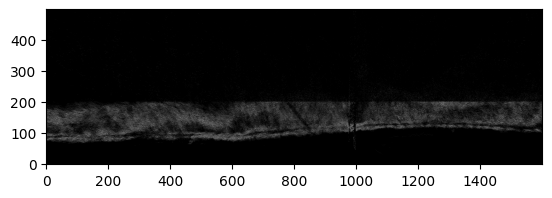

In [216]:
plt.imshow(count.T)

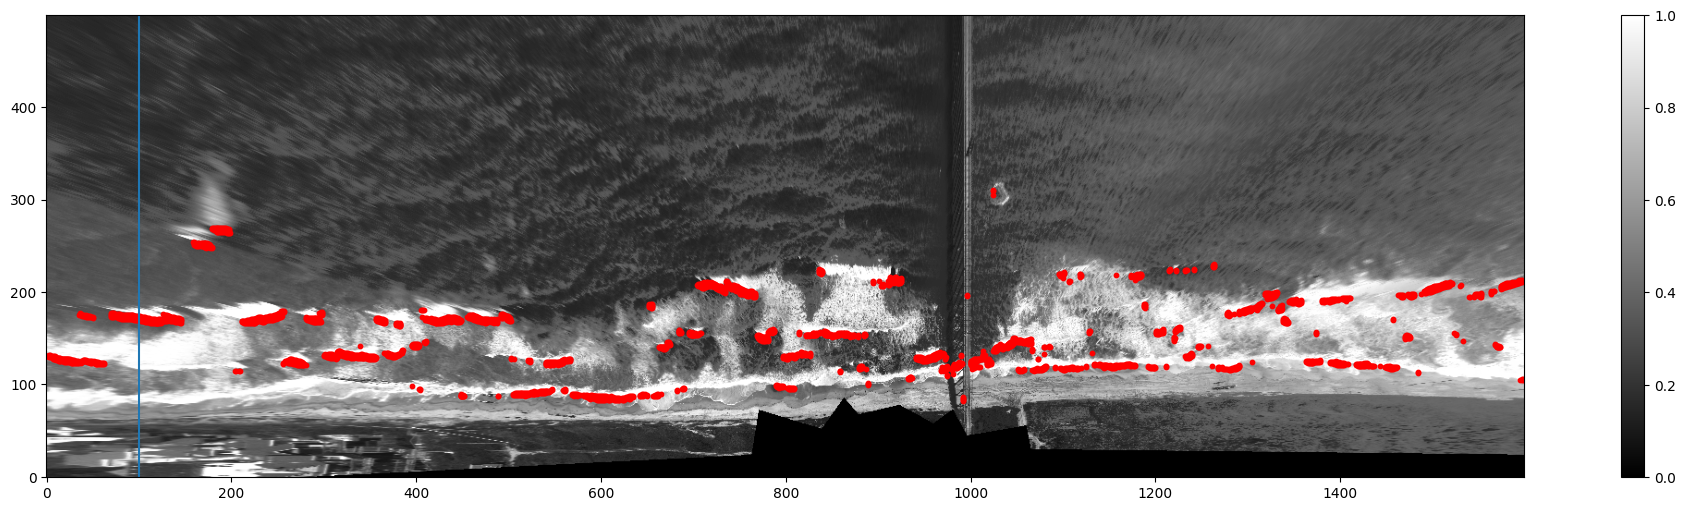

In [217]:
cap = cv2.VideoCapture(os.path.join(dir, file))
f = 51
for _ in range(f):
    _, frame = cap.read()
    frame = frame[..., 0]

plt.figure(figsize=(25,6))
plt.imshow(frame.T)
now = []
for i in range(len(peaks)):
    peak = filtered_peaks[i]
    if len(peak) != 0:
        peak = peak[:, peak[0, :]==f]
    if peak.size != 0:
        now_peaks = peak[..., :c]
        now.append(now_peaks[1, :])
        plt.scatter(np.ones_like(now_peaks[1, :]) * i, now_peaks[1, :], s=10, c='r')
# plt.scatter([np.arange(0, 1600, 10)]*c, np.array(peaks)[:, :c, f], s=5, c='r')
plt.axvline(100)
plt.colorbar()

(0.0, 500.0)

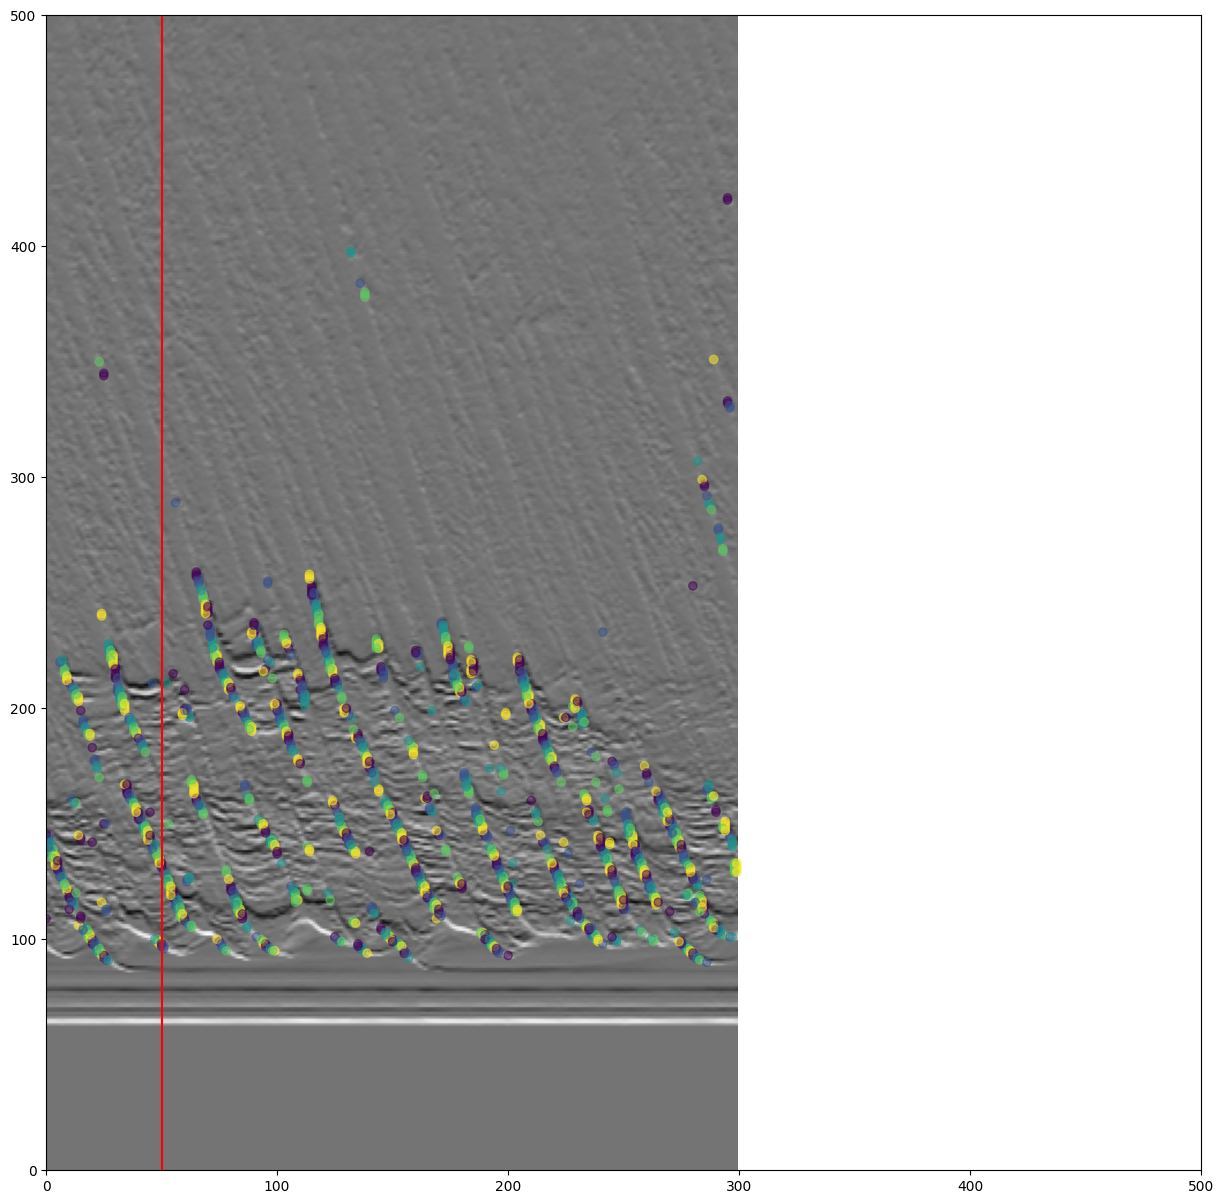

In [623]:
i = 800
plt.figure(figsize=(15, 15))
plt.imshow(sobel(timestack[:, i, :]).T)
plt.scatter(np.array([np.arange(timestack.shape[0])]*c), peaks[i][:c], c=[np.arange(c)]*timestack.shape[0], cmap='viridis', alpha=0.5)
# plt.axhline(surf_zone_min, c='k')
# plt.axhline(surf_zone_max, c='k')
plt.axvline(50, c='r')
plt.xlim(0, 500)
plt.ylim(0, 500)

35.728123600733326


Text(0, 0.5, 'Average Breaker Density')

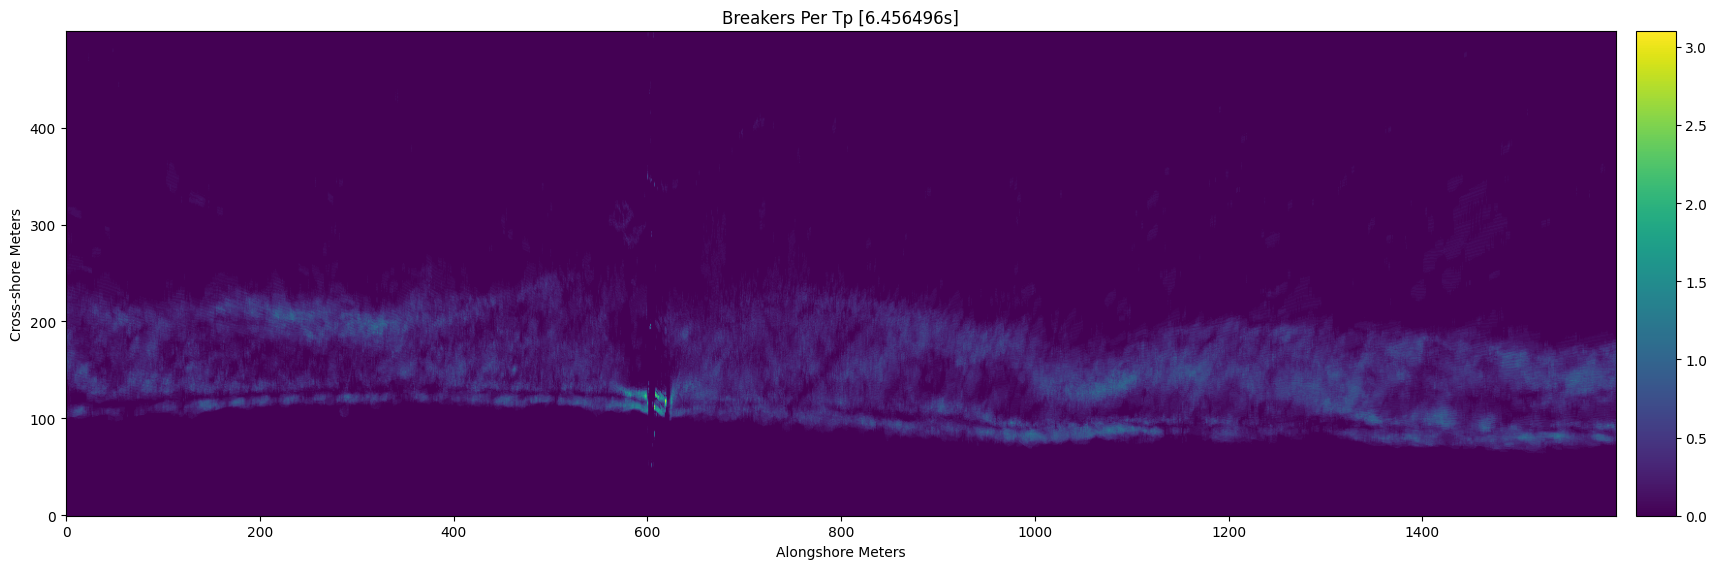

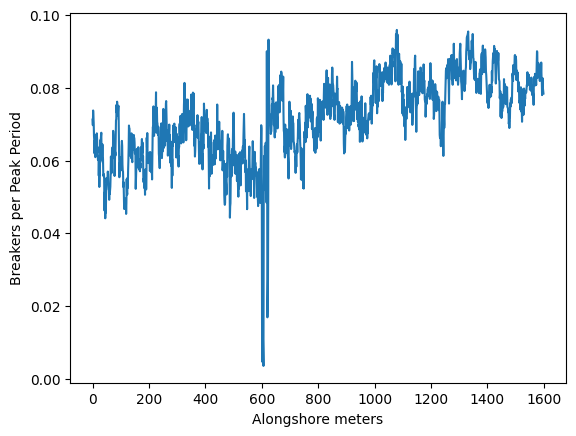

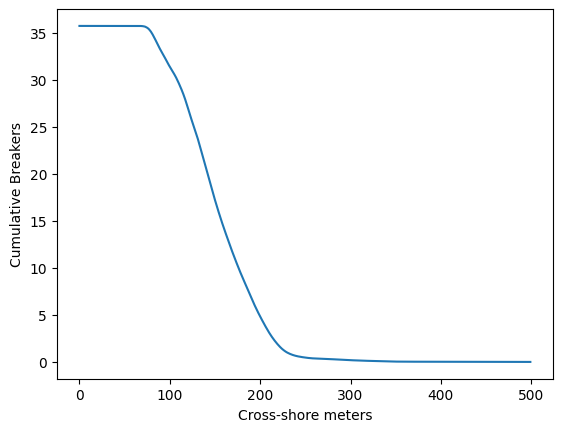

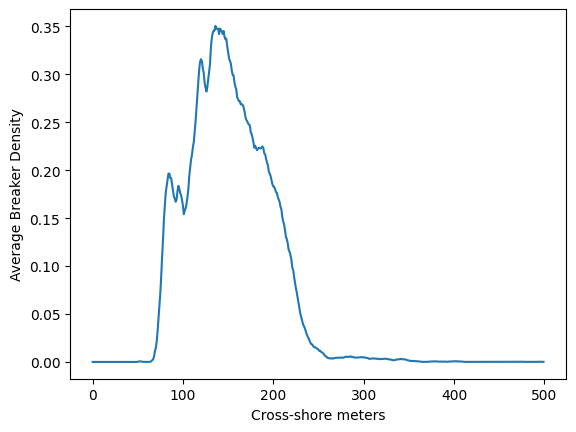

In [218]:
count = np.zeros((1600, 500))
for along, pks in enumerate(filtered_peaks):
    for t, cross in pks.T:
        count[along, cross] +=1
count = np.flip(count, 0)

T = timestack.shape[0] / FPS
# Tp = 6.456496

scale = 1
# scale = 1#c#8.9*c

fig, ax = plt.subplots(1,1,figsize=(20, 10))
ax.set_aspect(1)
plt.imshow(count.T/(T/Tp)/scale, cmap='viridis') # Breaker Density Per Peak Period
# plt.imshow(scipy.ndimage.gaussian_filter(count.T/(T/Tp)/2/c, sigma=(2,2)), cmap='viridis') # Breaker Density Per Peak Period
# plt.pcolormesh(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count/(T/Tp)), sigma=2), cmap='jet') # Breaker Density Per Peak Period
# plt.pcolormesh(*np.mgrid[0:1600, 0:500], (count/(T/Tp)), cmap='jet') # Breaker Density Per Peak Period
# plt.contourf(*np.mgrid[0:1600, 0:500], np.log10(1e-3+ scipy.ndimage.gaussian_filter((count/(T/Tp)), sigma=1)/scale), cmap='Reds', levels=10) # Breaker Density Per Peak Period
# plt.contourf(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count/(T/Tp)/scale), sigma=1), cmap='viridis', levels=40, vmax=0.025) # Breaker Density Per Peak Period
plt.xlabel('Alongshore Meters')
plt.ylabel('Cross-shore Meters')
plt.title(f'Breakers Per Tp [{Tp}s]')
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(cax=cax) # Similar to fig.colorbar(im, cax = cax)

plt.figure()
plt.plot((count.T/(T/Tp)/scale).mean(axis=0))
plt.xlabel('Alongshore meters')
plt.ylabel('Breakers per Peak Period')
print((count.T[0:800]/(T/Tp)/scale).sum(axis=0).mean(axis=0))


plt.figure()
plt.plot(np.cumsum((count.T[0:800, :]).mean(axis=1)[::-1])[::-1]/(T/Tp)/scale)
plt.xlabel('Cross-shore meters')
plt.ylabel('Cumulative Breakers')
# plt.ylim(0, 1)

plt.figure()
plt.plot((count.T[:, :]/(T/Tp)/scale).mean(axis=1))
plt.xlabel('Cross-shore meters')
plt.ylabel('Average Breaker Density')


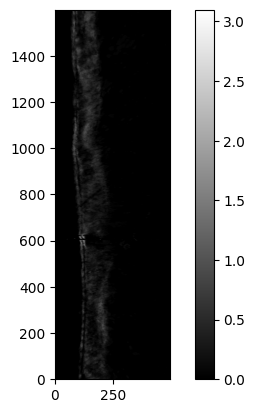

In [899]:
plt.imshow(np.flip(count/T*Tp, 0))
plt.colorbar()
# Count is # of breakers over T/c
# Count / T is breakers per second
# Count / T * Tp is breakers per peak period

0.9999999999999994


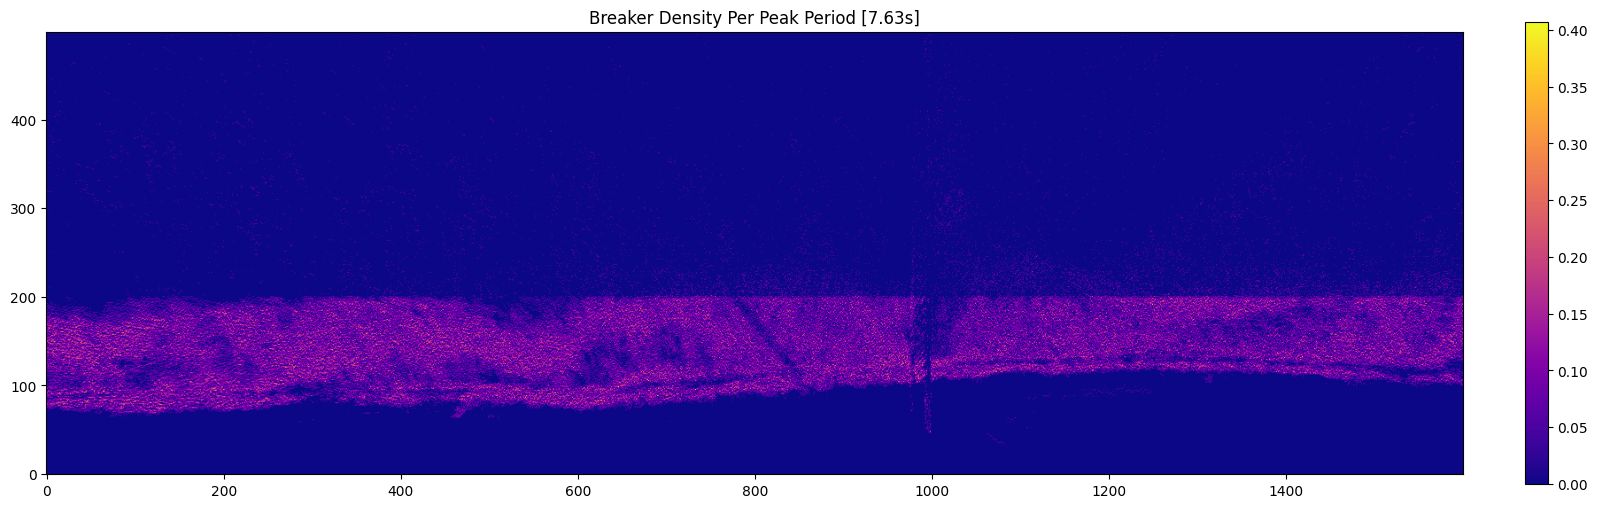

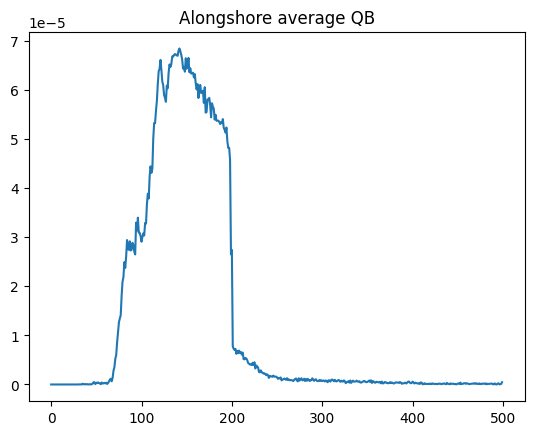

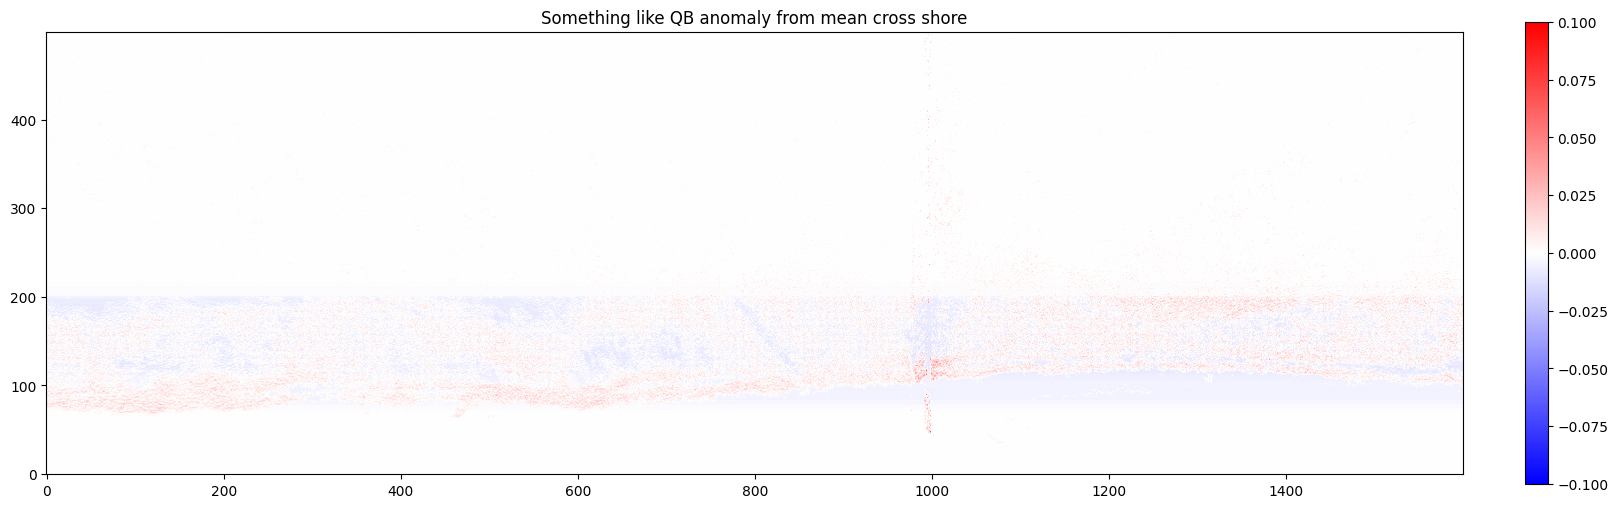

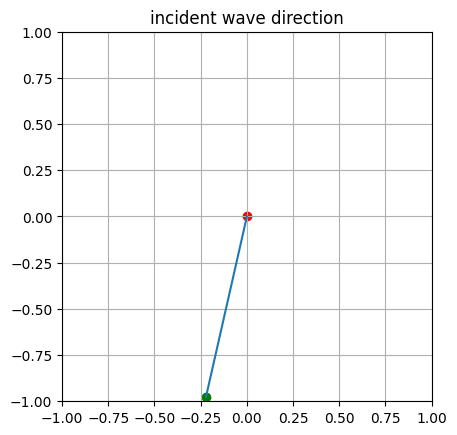

In [183]:
plt.figure(figsize=(20, 10))
# Tp = 7.631857
# plt.imshow(count.T/np.sum(count), cmap='hot') # Breaker Density
# plt.title('Breaker Density')
T = s.shape[0]/FPS
plt.imshow(count.T/(T/Tp), cmap='plasma') # Breaker Density Per Peak Period
plt.title(f'Breaker Density Per Peak Period [{Tp:.2f}s]')
# plt.imshow(count.T/np.sum(count.T, axis=0), cmap='hot', vmin=0.005, vmax=0.04) # along-shore variation of normalized cross shore density
plt.colorbar(fraction=0.046, pad=0.04, shrink=0.6)
plt.figure()
plt.plot((count.T/np.sum(count.T, axis=0)/T).mean(axis=1))
plt.title('Alongshore average QB')
print((count.T/np.sum(count.T, axis=0)).mean(axis=1).sum())

plt.figure(figsize=(20, 10))
Tp = 8
plt.title('Something like QB anomaly from mean cross shore')
plt.imshow(count.T/np.sum(count.T, axis=0) - (count.T/np.sum(count.T, axis=0)).mean(axis=1)[:, np.newaxis], cmap='bwr', vmin=-0.1, vmax=0.1)
plt.colorbar(fraction=0.046, pad=0.04, shrink=0.6)

plt.figure()
FRF_OFFSET = 71.8535
plt.plot([0, np.cos(39.450039 + FRF_OFFSET)], [0, np.sin(39.450039 + FRF_OFFSET)])
plt.scatter(0, 0, c='r')
plt.scatter(np.cos(39.450039 + FRF_OFFSET), np.sin(39.450039 + FRF_OFFSET), c='g')
plt.title('incident wave direction')
plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.gca().set_aspect('equal')
plt.grid()

In [225]:
from KDEpy import FFTKDE

cap = cv2.VideoCapture(os.path.join(dir, file))
_, frame = cap.read()
frame = frame[..., :]

b=breakers.T
kde = FFTKDE(kernel='gaussian', norm=2)
grid, points = kde.fit(b).evaluate((3200, surf_zone_max - surf_zone_min))
x, y = np.unique(grid[:, 0]), np.unique(grid[:, 1])
points = points.reshape(3200, surf_zone_max - surf_zone_min)
points = points #/ np.sum(points, axis=1)[:, np.newaxis]
z = points.T

plt.figure(figsize=(20, 8))
plt.imshow(frame[..., 0].T)
contours = 300
# plt.contourf(x, y, z, contours, cmap="hot", alpha=0.75)
plt.pcolormesh(x, y, z, cmap="hot", alpha=0.75)

plt.ylim(0, 500)
plt.xlim(0, 1600)
plt.colorbar(label='Per Cross Shore Breaker Density')


6.456495550475761


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_48903/983420815.py:63: RuntimeWarning: divide by zero encountered in divide
  breaking_fraction = np.array(num_breakers_in_bin)/np.array(num_waves_in_bin)
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_48903/983420815.py:63: RuntimeWarning: invalid value encountered in divide
  breaking_fraction = np.array(num_breakers_in_bin)/np.array(num_waves_in_bin)


NameError: name 'count' is not defined

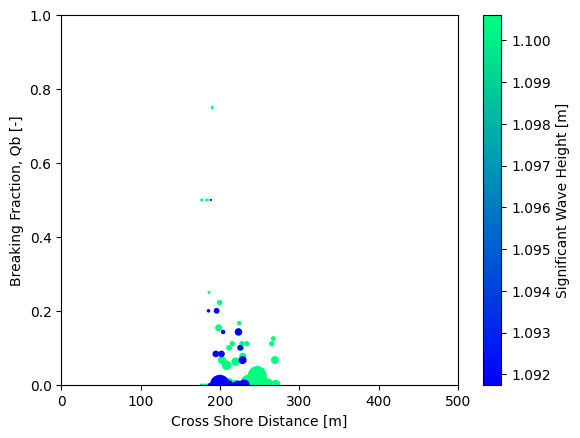

In [5]:
# Load the wave realization dataset
wave_df = pd.read_csv('/Users/mleclair/Dropbox/phd/code/dunex/drifters/DUNEXMainExp/analysis/../microSWIFT_data/wave_realizations_df.csv')
# Load the breaker dataset
breaker_df = pd.read_csv('/Users/mleclair/Dropbox/phd/code/dunex/drifters/DUNEXMainExp/analysis/../microSWIFT_data/breaker_df.csv')
# Load the mission dataset
mission_df = pd.read_csv('/Users/mleclair/Dropbox/phd/code/dunex/drifters/DUNEXMainExp/analysis/../microSWIFT_data/mission_df.csv')

Tp = mission_df[(mission_df['mission number'] == 32)]['Tm [s]'].item()
print(Tp)

# Organize the waves into Cross shore Distance Bins
mission_list = wave_df['mission number'].drop_duplicates()

# Define Cross Shore Bin Size
cross_shore_bin_size = 1

cross_shore_bin_centers_all = []
num_waves_in_bin_all = []
num_breakers_in_bin_all = []
breaking_fraction_all = []
hs_mission = []
tm_mission = []
mean_dir_mission = []
id_mission = []

# for mission_num in mission_list:
for mission_num in [31, 32]:
    # mission Specific Dataframes
    wave_df_mission = wave_df[wave_df['mission number'] == mission_num]
    breaker_df_mission = breaker_df[breaker_df['mission number'] == mission_num]
    mission_df_mission = mission_df[mission_df['mission number'] == mission_num]

    cross_shore_min = wave_df_mission['cross shore location [m]'].min()
    cross_shore_max = wave_df_mission['cross shore location [m]'].max()
    cross_shore_num_bins = int(np.floor((cross_shore_max - cross_shore_min)/ \
                                    cross_shore_bin_size))

    cross_shore_bin_edges = np.linspace(cross_shore_min, cross_shore_max,
                                        cross_shore_num_bins)

    cross_shore_bin_centers = (cross_shore_bin_edges[1:] + \
                           cross_shore_bin_edges[:-1]) / 2

    wave_heights_in_bins = []
    num_waves_in_bin = []
    for n in range(cross_shore_bin_centers.size):
        df = wave_df_mission[wave_df_mission['cross shore location [m]'].between(cross_shore_bin_edges[n], 
                                                                cross_shore_bin_edges[n+1])]
        wave_heights_in_bins.append(df['height [m]'])
        num_waves_in_bin.append(len(df.index))

    num_breakers_in_bin = []
    for n in range(cross_shore_bin_centers.size):
        df = breaker_df_mission[breaker_df_mission['cross shore location [m]'].between(cross_shore_bin_edges[n], 
                                                                cross_shore_bin_edges[n+1])]
        num_breakers_in_bin.append(len(df.index))

    cross_shore_bin_centers_all.append(cross_shore_bin_centers)
    num_waves_in_bin_all.append(num_waves_in_bin)
    num_breakers_in_bin_all.append(num_breakers_in_bin)

    # Compute breaking fraction
    breaking_fraction = np.array(num_breakers_in_bin)/np.array(num_waves_in_bin)
    breaking_fraction_all.append(breaking_fraction)

    # Add mission params
    hs_mission.append(mission_df_mission['Hs [m]'].iloc[0] * np.ones(breaking_fraction.size))
    tm_mission.append(mission_df_mission['Tm [s]'].iloc[0] * np.ones(breaking_fraction.size))
    mean_dir_mission.append(mission_df_mission['Mean Dir [deg]'].iloc[0] * np.ones(breaking_fraction.size))
    id_mission.append(mission_df_mission['mission number'].iloc[0] * np.ones(breaking_fraction.size))


cross_shore_bin_centers_all = np.concatenate(cross_shore_bin_centers_all)
breaking_fraction_all = np.concatenate(breaking_fraction_all)
hs_mission = np.concatenate(hs_mission)
tm_mission = np.concatenate(tm_mission)
mean_dir_mission = np.concatenate(mean_dir_mission)
id_mission = np.concatenate(id_mission)


fig, ax = plt.subplots()
sc = ax.scatter(cross_shore_bin_centers_all, breaking_fraction_all, 
                # c=id_mission, 
                c=hs_mission,
                s=(np.concatenate(num_waves_in_bin_all))**2/10, 
                cmap='winter', label='In Situ Qb')
cbar = fig.colorbar(sc)
cbar.set_label('Significant Wave Height [m]')
# cbar.set_label('Mission ID')
ax.set_ylim(0, 1)
ax.set_xlabel('Cross Shore Distance [m]')
ax.set_ylabel('Breaking Fraction, Qb [-]')
ax.set_xlim(0, 500)
scale = 1
l = ax.plot((count.T[0:800, :]/(T/Tp)/scale).mean(axis=1), label=f'Breakers per Tp [{Tp}s]')
elements, labels = sc.legend_elements("sizes", num=5, func=lambda x: np.sqrt(x*10))
legend1 = plt.legend(elements, [f'{l}' for l in labels], loc=1, title='SWIFT\nObservations')
plt.legend(l, [f'ARGUS Breakers per Tp [{Tp}s]'], loc=2)
plt.gca().add_artist(legend1)

# plt.legend(elements + l,  + [f'Breakers per Tp [{Tp}s]'])

# plt.xlabel('Cross-shore meters')
# plt.ylabel('Average Breaker Density')


In [461]:
mission_df[(mission_df['mission number'] == 31) |
           (mission_df['mission number'] == 32)]

,Unnamed: 0,time,mission number,Hs [m],Tm [s],Mean Dir [deg],cross shore gamma location [m],break depth,freq [hz],energy density [m^2\hz],direction bins [deg],directional energy density [m^2/hz/deg],wind speed [m/s],wind direction [deg],water level [m]
39,39,2021-10-13 17:25:29.998680,32,1.091753,6.456496,59.175695,263.470935,3.119293,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.01459356204863603, 0.013802312733134417, 0....","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[4.0894119592849165e-05, 4.2284758819732815e-...",6.483833,4.238652,0.781
54,54,2021-10-13 16:32:29.997480,31,1.100600,6.409570,57.881106,264.644041,3.144571,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.014066558259197441, 0.013176852610816579, 0...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[4.0894119592849165e-05, 4.2284758819732815e-...",6.558333,9.868387,0.662


In [686]:
import xarray as xr
qb = xr.load_dataset('../../model/output/qb32.nc')

/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/xarray/core/indexing.py:630: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


In [220]:
bathy = xr.load_dataset('../../model/code/bathy/ocean_dunex_grd32.nc')
bathy['h'].values[bathy.h.values <= 0] = np.nan
D = (-bathy.h.sel(eta_rho=400))
missions = pd.read_csv('../../data/mission_df.csv')
mission = missions[missions['mission number']==32]

H_s = mission['Hs [m]'].item()
H_rms = H_s / 1.42 # TG89
N = 17 * 60 / mission['Tm [s]'].item() # TG89
H_max = (np.log(N)**0.5 +
         (0.2886 * np.log(N)**-0.5))*H_rms # TG89 (Cartwright and Longuet-Higgins 56)
H = np.linspace(0, H_max, 100)
p = lambda H: 2*H / H_rms**2 * np.exp(-(H/H_rms)**2)
h = D.values
n = 4
gamma = 0.35

w = lambda H: np.minimum((H_rms/gamma/h)**n * (1 - np.exp(-(H/gamma/h)**2)), 1)
pb =  lambda H: p(H)[:, np.newaxis] * w((np.ones(901)[:, np.newaxis] * H[np.newaxis, :]).T)


QB = np.zeros_like(bathy.h.values)
for i in range(1001):
    D = -(bathy.h.isel(eta_rho=i) + mission['water level [m]'].item())
    h = D.values
    w = lambda H: np.minimum(
        (H_rms/gamma/h)**n * (1 - np.exp(-(H/gamma/h)**2)),
        1)
    p = lambda H: 2*H / H_rms**2 * np.exp(-(H/H_rms)**2)
    pb = p(H)[:, np.newaxis] * w((np.ones(901)[:, np.newaxis] * H[np.newaxis, :]).T) # waves, cross-shore
    QB[i, :] = np.mean(pb, axis=0) # Averaged over waves 


NameError: name 'xr' is not defined

In [1070]:
ph = [p(H)]

for i in range(900):
    h = bathy.h.dropna(dim='xi_rho').mean(dim='eta_rho').values[-i]
    w = lambda H: np.minimum(
        (H_rms/gamma/h)**n * (1 - np.exp(-(H/gamma/h)**2)),
        1)
    pb = ph[-1][:, np.newaxis] * w(H[np.newaxis, :]).T # waves, cross-shore
    # pb = np.nanmean(pb, axis=0)
    print(w(H))
    print(pb)
    print(ph)
    ph.append(ph[-1]-pb)

[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]
[[0.        ]
 [0.06245507]
 [0.12469407]
 [0.18650217]
 [0.24766704]
 [0.30798004]
 [0.36723738]
 [0.42524135]
 [0.48180132]
 [0.53673486]
 [0.58986866]
 [0.64103948]
 [0.69009496]
 [0.73689433]
 [0.78130911]
 [0.82322367]
 [0.86253563]
 [0.89915632]
 [0.93301094]
 [0.96403883]
 [0.99219346]
 [1.0174424 ]
 [1.03976725]
 [1.05916336]
 [1.07563952]
 [1.08921761]
 [1.09993208]
 [1.10782944]
 [1.11296761]
 [1.11541528]
 [1.11525117]
 [1.11256323]
 [1.10744791]
 [1.10000922]
 [1.09035797]
 [1.07861081]
 [1.06488941]
 [1.04931951]
 [1.03203014]
 [1.01315267]
 [0.99282   ]
 [0.97116577]
 [0.94832352]
 [0.92442599]
 [0.8996044 ]
 [0.87398776]
 [0.84770228]
 [0.82087078]
 [0.79361221]
 [0.7660

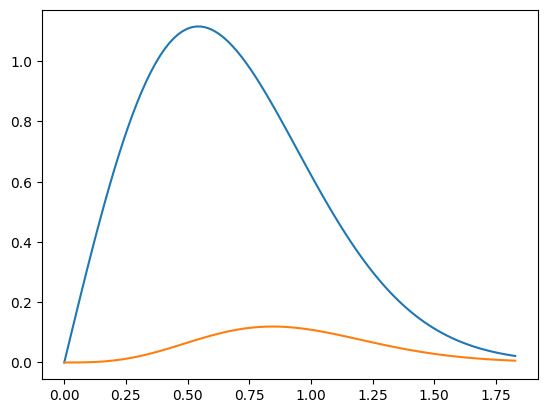

In [1039]:
QB = np.zeros_like(bathy.h.values)
i = 50
D = -(bathy.h.isel(eta_rho=i) + mission['water level [m]'].item())
h = D.values
w = lambda H: np.minimum(
    (H_rms/gamma/h)**n * (1 - np.exp(-(H/gamma/h)**2)),
    1)
p = lambda H: 2*H / H_rms**2 * np.exp(-(H/H_rms)**2)
pb = p(H)[:, np.newaxis] * w((np.ones(901)[:, np.newaxis] * H[np.newaxis, :]).T) # waves, cross-shore
QB[i, :] = np.mean(pb, axis=0) # Averaged over waves 
plt.plot(H, p(H), )
plt.plot(H, pb[:, 200])

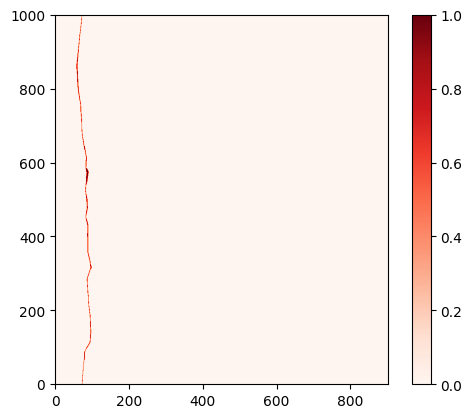

In [1029]:
plt.imshow(bathy.h)
plt.imshow(bathy.h<0.1, cmap='Reds')
plt.colorbar()

In [171]:
count

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

NameError: name 'bathy' is not defined

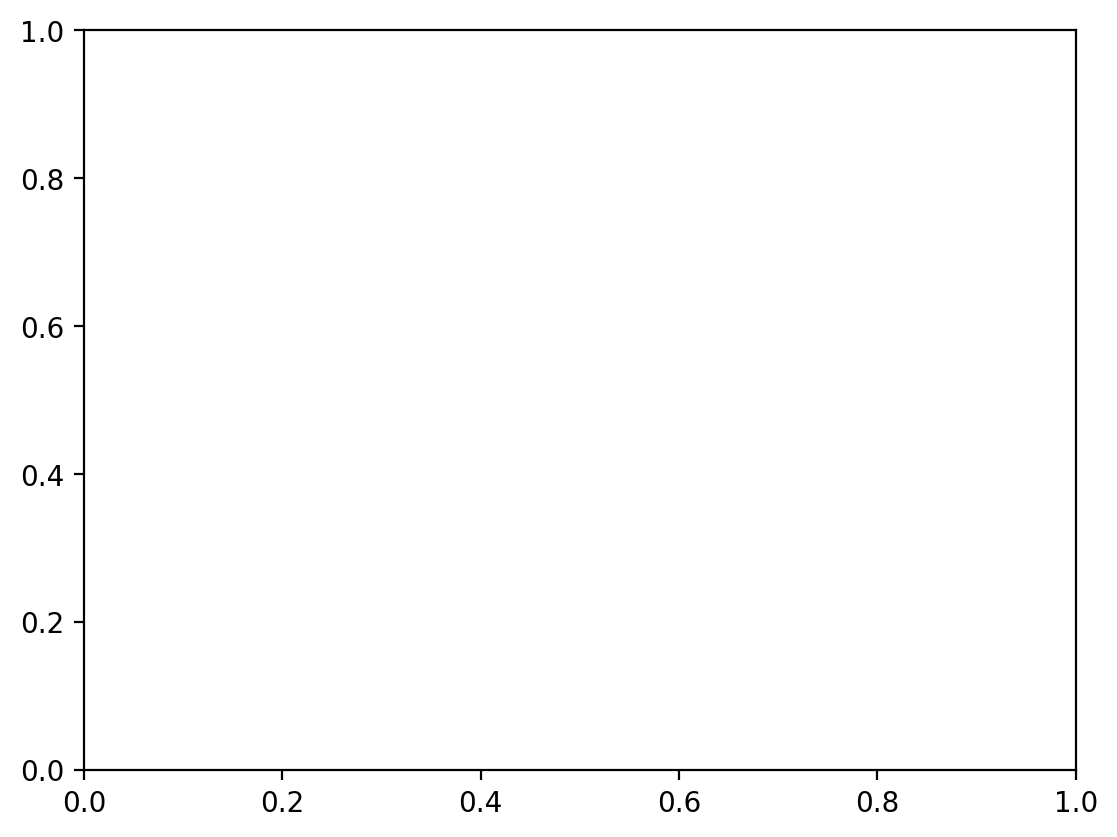

In [219]:
fig, ax = plt.subplots(dpi=200)
mission_colors = list(map(lambda x: plt.cm.tab10.colors[int(x)], id_mission-31))

h = bathy.h.mean(axis=0)

sc = ax.scatter(h[cross_shore_bin_centers_all], breaking_fraction_all, 
                c=mission_colors, 
                # c=m,
                s=(np.concatenate(num_waves_in_bin_all))**2/10, 
                cmap='tab10', label='In Situ Qb')
# cbar = fig.colorbar(sc)
cbar.set_label('Significant Wave Height [m]')
cbar.set_label('Mission ID')
ax.set_ylim(0, 1.1)
ax.set_xlabel('Cross Shore Distance [m]')
ax.set_ylabel('Breaking Fraction, Qb [- or Crest/Tp]')
ax.set_xlim(0, 500)
scale = 1

# l = ax.plot(
#     (count31.T[:, :]/(60/Tp)*scale).mean(axis=1)
#     , label=f'Mission 31 [{mission_df[mission_df['mission number']==31].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [60s]')
l = ax.plot(
    h,
    (count32.T[:, :]/(60/Tp)*scale).mean(axis=1),
    label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [{60}s]')
l = ax.plot(
    h,
    (count.T[:, :]/(T/Tp)*scale).mean(axis=1),
    label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [{T}s]',
    c='tab:orange', linestyle='--')

start = 0
# l = ax.plot(
#     np.linspace(start, 500 + start - 1, 500),
#     np.nanmean(qb.Wave_break, axis=0)[0:500],
#     label='SWAN Qb'
# )
start = 0

# ax.plot(
#     np.linspace(start, 900 + start, 901),
#     np.nanmean(QB, axis=0), label='TG \'89 Qb'
# )

elements, labels = sc.legend_elements("sizes", num=5, func=lambda x: np.sqrt(x*10))
legend1 = plt.legend(elements, [f'{l}' for l in labels], loc=4, title='SWIFT\nObservations')
h, l = ax.get_legend_handles_labels()
plt.legend(h[1:], l[1:], loc=1)
plt.gca().add_artist(legend1)
plt.title(f'Mission 32\n{mission_df[mission_df['mission number']==32].time.item()[:10]}')


Text(0.5, 0.95, 'Mission 32 Argus Breaker Density')

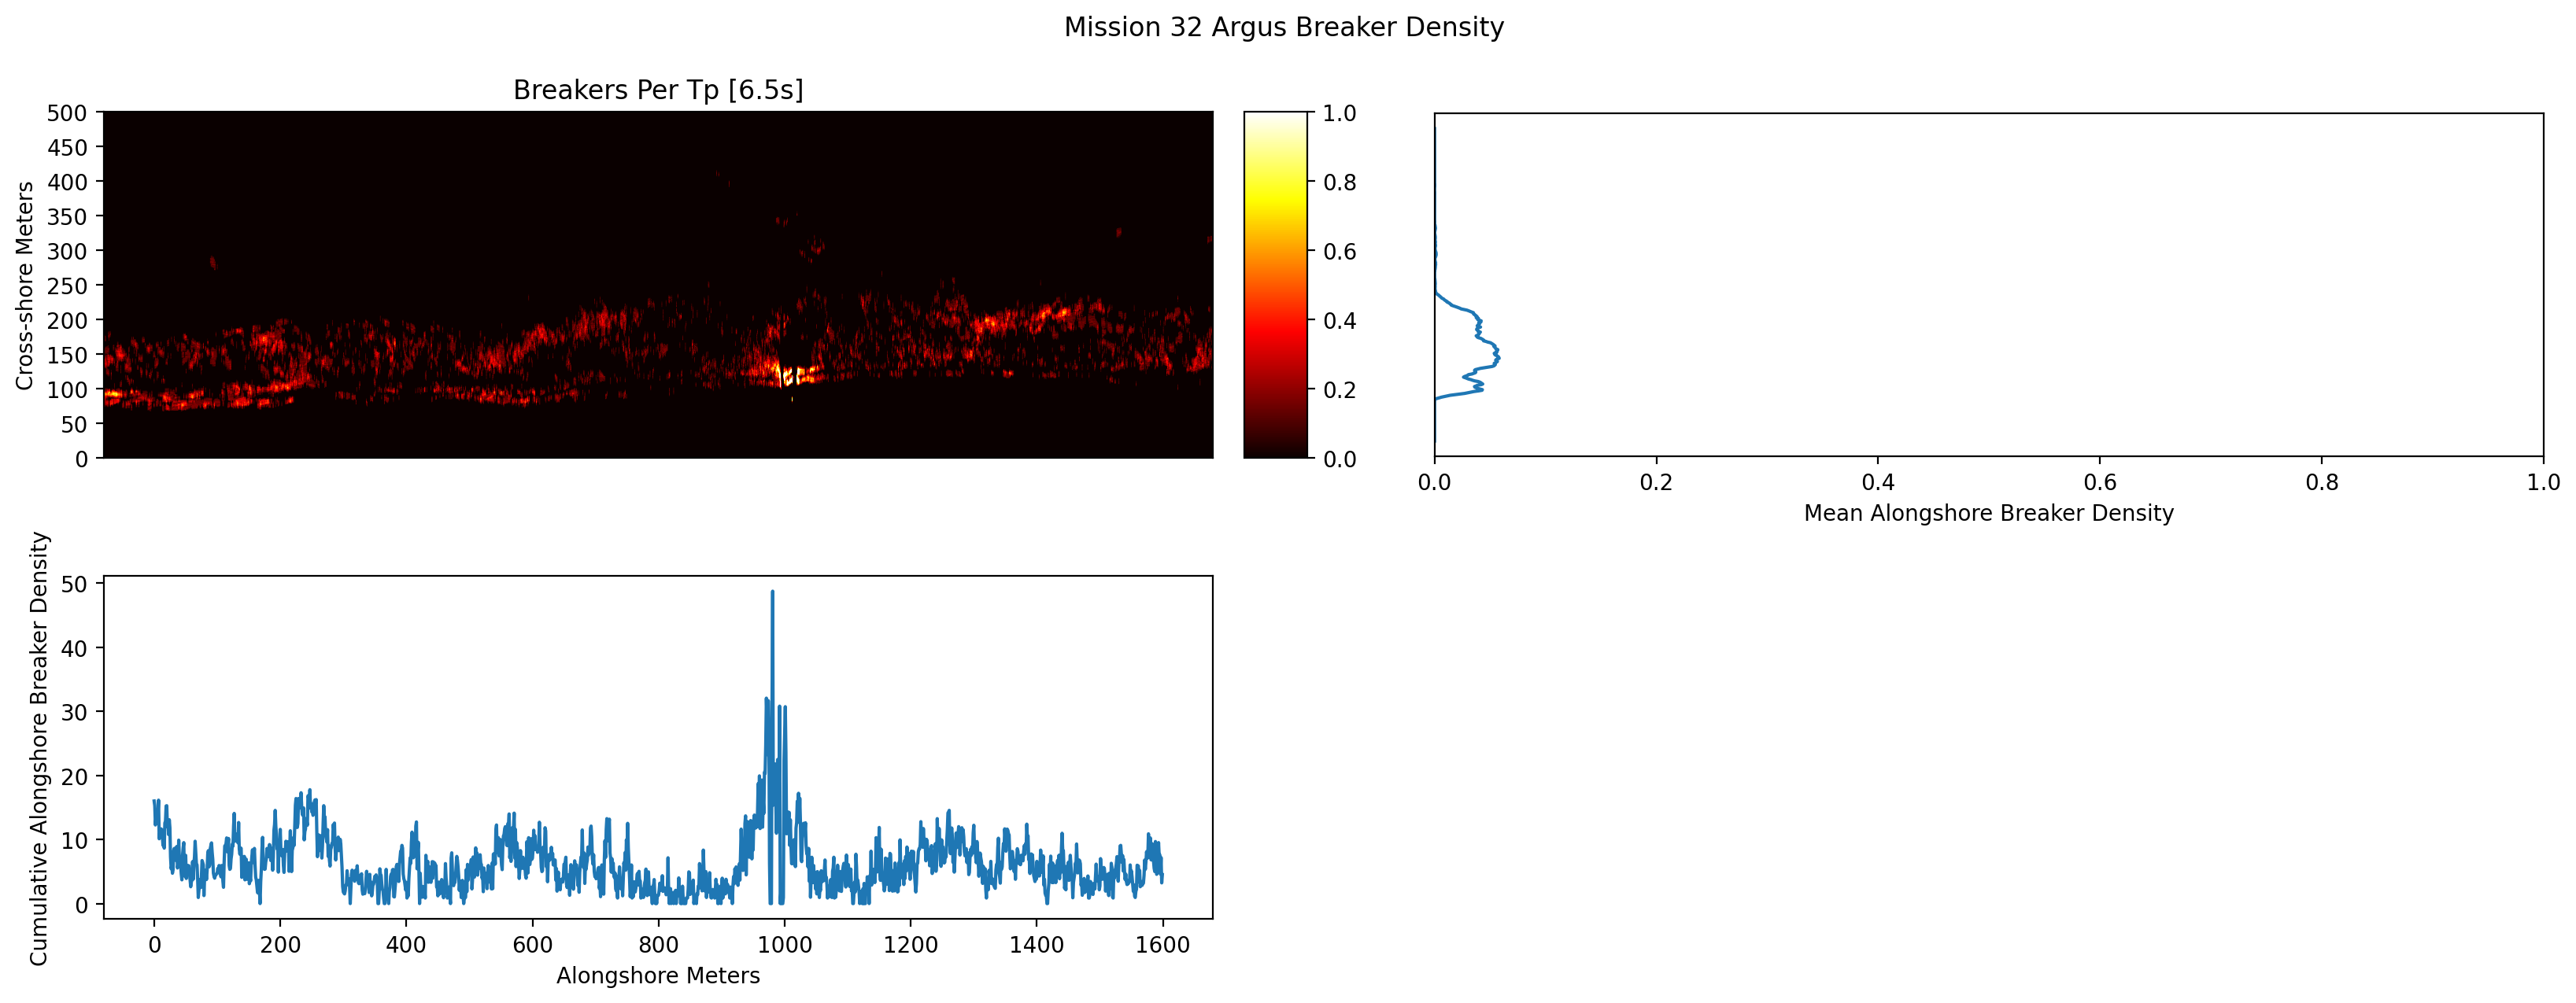

In [211]:
count = np.zeros((1600, 500))
for along, pks in enumerate(filtered_peaks):
    for t, cross in pks.T:
        count[along, cross] +=1
# count = np.flip(count, 0)

T = timestack.shape[0] / FPS
Tp = 6.456496

scale = 1
# scale = 1#c#8.9*c

#####################################
fig, axs = plt.subplots(2,2,figsize=(20, 7), dpi=200)
ax = axs[0][0]
ax.set_aspect(1)
im = ax.imshow(count.T/(T/Tp)/scale, cmap='hot', vmax=1) # Breaker Density Per Peak Period
# ax.imshow(scipy.ndimage.gaussian_filter(count.T/(T/Tp)/2/c, sigma=(2,2)), cmap='viridis') # Breaker Density Per Peak Period
# ax.pcolormesh(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count/(T/Tp)), sigma=2), cmap='jet') # Breaker Density Per Peak Period
# ax.pcolormesh(*np.mgrid[0:1600, 0:500], (count/(T/Tp)), cmap='jet') # Breaker Density Per Peak Period
# ax.contourf(*np.mgrid[0:1600, 0:500], np.log10(1e-3+ scipy.ndimage.gaussian_filter((count/(T/Tp)), sigma=1)/scale), cmap='Reds', levels=10) # Breaker Density Per Peak Period
ax.set_ylabel('Cross-shore Meters')
# im = ax.contourf(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count/(T/Tp)/scale), sigma=1), cmap='hot', levels=50) # Breaker Density Per Peak Period
ax.set_title(f'Breakers Per Tp [{Tp:.1f}s]')
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax)
ax.set_xticks([])
ax.set_yticks(np.linspace(0, 500, 11))
#####################################
ax = axs[1][0]
ax.plot((count.T/(T/Tp)/scale).sum(axis=0))
ax.set_ylabel('Cumulative Breaker Density')
xvals,yvals = ax.get_xlim(),ax.get_ylim()
xrange = xvals[1]-xvals[0]
yrange = yvals[1]-yvals[0]
ax.set_aspect(0.31*(xrange/yrange), adjustable='box')
ax.set_xlabel('Alongshore Meters')
ax.set_ylabel('Cumulative Alongshore Breaker Density')
#####################################
ax = axs[0][1]
ax.plot((count.T[:, :]/(T/Tp)/scale).mean(axis=1), np.linspace(0, 499, 500))
ax.set_xlim(0, 1)
xvals,yvals = ax.get_xlim(),ax.get_ylim()
ax.set_yticks([])
xrange = xvals[1]-xvals[0]
yrange = yvals[1]-yvals[0]
ax.set_aspect(0.31*(xrange/yrange), adjustable='box')
ax.set_xlabel('Mean Alongshore Breaker Density')

axs[1][1].set_visible(False)
fig.suptitle('Mission 32 Argus Breaker Density', y=0.95)

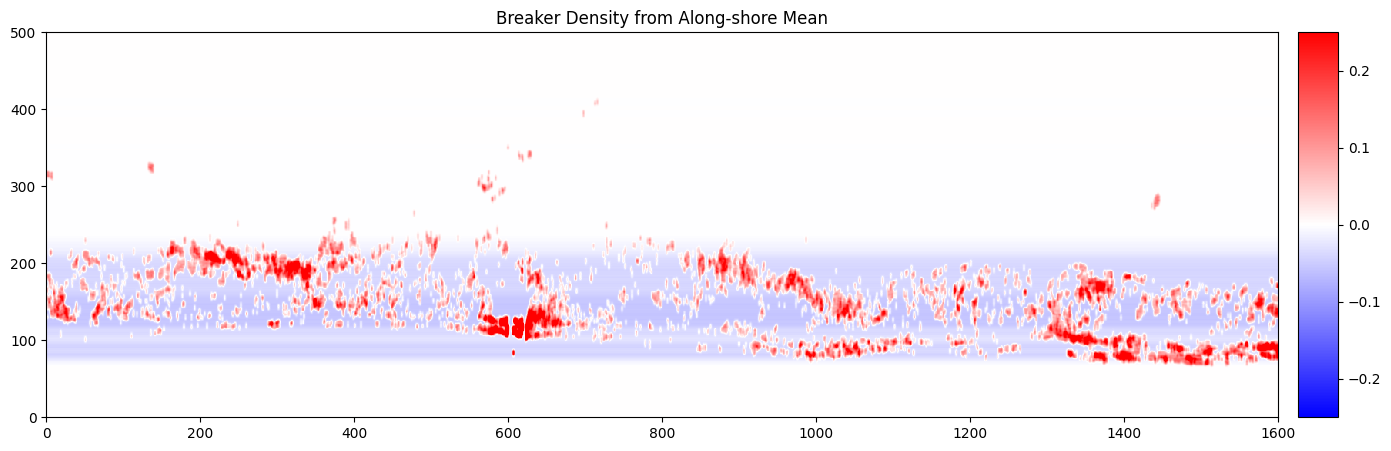

In [208]:
fig, ax = plt.subplots(1,1, figsize=(20, 5))
im = ax.pcolormesh(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count/(T/Tp)/scale), sigma=1)
                 -(count.T[:, :]/(T/Tp)/scale).mean(axis=1) , cmap='bwr', vmin=-0.25, vmax=0.25)
#levels=np.linspace(-0.25, 0.25, 21)) # Breaker Density Per Peak Period
plt.xlim(0, 1600)
plt.title('Breaker Density from Along-shore Mean')
plt.ylim(0, 500)
plt.gca().set_aspect(1)
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax)


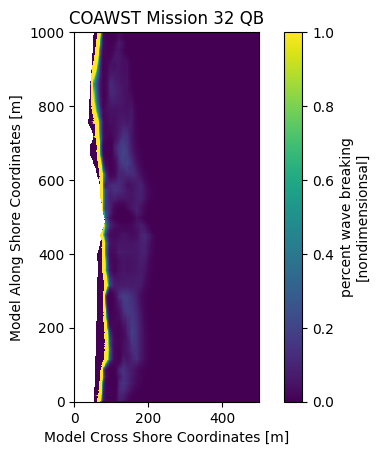

In [969]:
qb.Wave_break.plot(cmap='viridis')
plt.xlim(0, 500)
plt.title('COAWST Mission 32 QB')
plt.xlabel('Model Cross Shore Coordinates [m]')
plt.ylabel('Model Along Shore Coordinates [m]')
plt.gca().set_aspect('equal')